# 🧪 Day 46 — Week 3 Mini-Project: End-to-End EDA with Feature Engineering
**Month 3 · Week 3 Capstone · Python + Pandas + Matplotlib + Seaborn**

---

> **Scenario — NovaMart Analytics:**
> You are a freelance data analyst hired by **NovaMart**, a national e-commerce retailer.
> Their Head of Growth has dropped a raw transaction file on your desk:
>
> *"We've been running for 18 months. I know we have some product lines that are dead weight,
> some regions under-performing, and a discount strategy that I suspect is losing us money.
> I need a clean analysis, real charts, and three things I can act on — by end of day."*
>
> No template. No hints. You have raw data, a business problem, and a deadline.
> **Clean → Engineer → Analyse → Visualise → Narrate.**

---

## Skills Tested (Week 3 Review)

| Skill | Day Covered |
|---|---|
| Insight-titled charts, savefig, multi-panel layout | Day 42 — Advanced Visualization |
| 5-phase EDA: orient → diagnose → clean → explore → narrate | Day 43 — EDA Framework |
| Distributions, describe, scatter, correlation | Day 44 — Univariate + Bivariate |
| Derived columns, binning, date parts, ratio features | Day 45 — Feature Engineering |

---

## Scoring

| Section | Focus | Points |
|---------|-------|--------|
| A | Data Audit + Cleaning | 20 |
| B | Feature Engineering | 20 |
| C | Univariate + Bivariate Analysis | 20 |
| D | Visualisation Dashboard | 15 |
| E | Executive Summary | 5 |
| **Total** | | **80** |
| ⭐ Bonus | All 4 bonus criteria met | +10 |

---


## 📁 Section 1 — Raw Data *(never modify `df_raw`)*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

random.seed(42)
np.random.seed(42)

regions    = ['North', 'South', 'East', 'West']
categories = ['Electronics', 'Apparel', 'Home & Kitchen', 'Beauty', 'Sports']
channels   = ['App', 'Website', 'In-Store']
return_reasons = ['Defective', 'Wrong item', 'Changed mind', None, None]

rows = []
base = pd.Timestamp('2023-01-01')

for i in range(1, 251):
    region   = random.choice(regions)
    cat      = random.choice(categories)
    channel  = random.choice(channels)
    qty      = random.randint(1, 6)
    unit_p   = round(random.uniform(150, 9500), 2)
    discount = round(random.uniform(0, 40), 1)
    ship     = round(random.uniform(25, 350), 2)

    # spread across 18 months (Jan 2023 – Jun 2024)
    order_date = base + pd.Timedelta(days=random.randint(0, 547))
    delivery_days = random.randint(1, 14)

    # deliberate data quality issues
    if random.random() < 0.04:   # 4% duplicate-ish rows
        unit_p = -unit_p         # negative price flag
    if random.random() < 0.06:   # 6% nulls in channel
        channel = None
    if random.random() < 0.05:   # 5% nulls in discount
        discount = None

    revenue = round(qty * abs(unit_p) * (1 - (discount or 0)/100), 2)
    is_ret  = 1 if random.random() < 0.18 else 0
    reason  = random.choice(return_reasons) if is_ret else None

    rows.append({
        'order_id'      : f'NM{i:04}',
        'order_date'    : order_date.strftime('%Y-%m-%d'),
        'region'        : region,
        'category'      : cat,
        'channel'       : channel,
        'quantity'      : qty,
        'unit_price'    : unit_p,
        'discount_pct'  : discount,
        'shipping_cost' : ship,
        'revenue'       : revenue,
        'delivery_days' : delivery_days,
        'is_return'     : is_ret,
        'return_reason' : reason
    })

df_raw = pd.DataFrame(rows)
df = df_raw.copy()

print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()


Shape: (250, 13)

Column dtypes:
order_id          object
order_date        object
region            object
category          object
channel           object
quantity           int64
unit_price       float64
discount_pct     float64
shipping_cost    float64
revenue          float64
delivery_days      int64
is_return          int64
return_reason     object
dtype: object

First 5 rows:


,order_id,order_date,region,category,channel,quantity,unit_price,discount_pct,shipping_cost,revenue,delivery_days,is_return,return_reason
0,NM0001,2023-03-31,North,Electronics,None,3,2439.74,5.6,58.31,6909.34,10,0,None
1,NM0002,2023-10-12,North,Sports,App,6,6226.42,21.8,96.64,29214.36,13,0,None
2,NM0003,2023-12-19,East,Apparel,None,3,1105.67,15.2,141.67,2812.82,10,1,None
3,NM0004,2023-03-13,North,Sports,Website,6,5933.16,34.5,212.64,23317.32,1,0,None
4,NM0005,2023-08-03,North,Beauty,Website,4,6093.65,14.6,145.31,20815.91,11,0,None


## 📚 Section 2 — Concept Notes (Mini-Project Reference)

### What this mini-project tests

This is not a lesson. There are no scaffolded hints.
Each task states the business question — you decide the method.

**Decision flowchart:**

```
Business question
       ↓
Is it about shape/distribution of one column?     → Univariate (histogram, describe, value_counts)
Is it about relationship between two columns?      → Bivariate (scatter, groupby, corr)
Is it about creating new signal from existing cols? → Feature Engineering (derived, bin, date, ratio)
Is it about presenting findings to a client?        → Chart with insight title + NRA narration
```

---

### Reminders from Days 42–45

**Insight titles** (Day 42): state the *so what*, not the data.
- ❌ `"Revenue by Region"` — describes the chart
- ✅ `"North leads revenue by 34% — replicate its channel mix in South"` — tells the story

**EDA phases** (Day 43): orient → diagnose → clean → explore → narrate. Never skip diagnose.

**NRA format** (throughout): **Number + Reason + Action** in every written output.

**Feature engineering** (Day 45): derive → bin → date-extract → ratio.
Always ask: *"Would this feature exist at prediction time?"*

**savefig before show** (Day 42): `plt.savefig(...)` must come before `plt.show()` — never after.

---


## ✏️ Section 3 — Practice Tasks

> Write plain-English comments first. Then fill in code.
> Work on `df` — never modify `df_raw`.


### 🔵 Section A — Data Audit + Cleaning (20 pts)

**A1 — Audit Report (8 pts)**

Print a structured audit covering all five of these:
1. Shape (rows × columns)
2. Null count per column (only show columns with nulls)
3. Count of rows where `unit_price < 0` (these are data errors)
4. Dtype of `order_date` (should be datetime — is it?)
5. Duplicate `order_id` count

Format as printed lines — one finding per line. No markdown tables needed.

**A2 — Clean the DataFrame (12 pts)**

Fix all issues found in A1:
- Remove rows where `unit_price < 0`
- Fill nulls in `discount_pct` with the **median** discount
- Fill nulls in `channel` with `'Unknown'`
- Convert `order_date` to datetime
- Drop duplicate `order_id` rows if any exist (keep first)

After cleaning, assert:
- No negative `unit_price` values remain
- No nulls in `discount_pct` or `channel`
- `order_date` dtype is datetime64

Print: `"Cleaning complete — shape: {rows} × {cols}"`


In [3]:
# A1 — Data Audit
print("Audit Report")
print(f"1. Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
null_cols = df_raw.isnull().sum()
null_cols = null_cols[null_cols > 0]
print(f"2. Nulls:\n{null_cols.to_string()}")
print(f"3. Negative unit_price rows: {(df_raw['unit_price'] < 0).sum()}")
print(f"4. order_date dtype: {df_raw['order_date'].dtype} (should be datetime after conversion)")
print(f"5. Duplicate order_ids: {df_raw['order_id'].duplicated().sum()}")

Audit Report
1. Shape: 250 rows x 13 columns
2. Nulls:
channel           10
discount_pct       9
return_reason    229
3. Negative unit_price rows: 5
4. order_date dtype: object (should be datetime after conversion)
5. Duplicate order_ids: 0


In [4]:
# A2 — Data Cleaning
df = df_raw.copy()
df = df[df['unit_price'] >=0]
df['discount_pct'] = df['discount_pct'].fillna(df['discount_pct'].median())
df['channel'] = df['channel'].fillna('Unknown')
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.drop_duplicates(subset='order_id', keep='first')

assert (df['unit_price']< 0).sum() ==0
assert df['discount_pct'].isnull().sum() == 0
assert df['channel'].isnull().sum() == 0
assert str(df['order_date'].dtype).startswith('datetime')

print(f"Cleaning complete - shape: {df.shape[0]} x {df.shape[1]}")



Cleaning complete - shape: 245 x 13


### 🟡 Section B — Feature Engineering (20 pts)

**B1 — Four Engineered Features (12 pts)**

Create all four in one block:
1. `net_revenue` = `revenue − shipping_cost`
2. `price_tier` using `pd.cut` on `unit_price`:
   - Budget: ₹0–₹1,500 | Mid: ₹1,500–₹4,000 | Premium: ₹4,000–₹7,000 | Luxury: ₹7,000–₹10,000
   - Use `include_lowest=True`
3. `order_month` and `order_quarter` extracted from `order_date`
4. `shipping_ratio` = `shipping_cost / revenue`, rounded to 4 dp

After creating all four, print `df[['net_revenue','price_tier','order_month','order_quarter','shipping_ratio']].head(5)`

**B2 — Segment Insight (8 pts)**

Compute mean `net_revenue` per `price_tier`, sorted descending.
Then compute mean `shipping_ratio` per `price_tier`, sorted descending.

Print both tables.

Write one `print()` insight combining both: which tier has the best net revenue but also the worst shipping ratio? What should operations do about it? Use **NRA format**.


In [5]:
# B1 — Four Engineered Features
# Create all four, then print head(5)
df['net_revenue'] = df['revenue'] - df['shipping_cost']
df['price_tier']  = pd.cut(df['unit_price'],
                           bins = [0, 1500, 4000, 7000, 10000],
                           labels = ['Budget', 'Mid', 'Premium', 'Luxury'],
                           include_lowest = True)
df['order_month'] = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter
df['shipping_ratio'] = (df['shipping_cost'] / df['revenue']).round(4)

print(df[['net_revenue', 'price_tier', 'order_month', 'order_quarter', 'shipping_ratio']].head(5))


   net_revenue price_tier  order_month  order_quarter  shipping_ratio
0      6851.03        Mid            3              1          0.0084
1     29117.72    Premium           10              4          0.0033
2      2671.15     Budget           12              4          0.0504
3     23104.68    Premium            3              1          0.0091
4     20670.60    Premium            8              3          0.0070


In [6]:
# B2 — Segment Insight
# Mean net_revenue and shipping_ratio per price_tier
net_by_tier = df.groupby('price_tier', observed = True)['net_revenue'].mean().sort_values(ascending = False)
shr_by_tier = df.groupby('price_tier', observed = True)['shipping_ratio'].mean().sort_values(ascending = False)

print("Mean net_revenue per price_tier:")
print(net_by_tier.round(2))
print("\nMean shipping_ratio per price_tier:")
print(shr_by_tier.round(4))
# Then NRA print insight
best_net = net_by_tier.index[0]
worst_shr = shr_by_tier.index[0]
print(f"\n{best_net} delivers the highest net revenue (₹{net_by_tier.iloc[0]:,.0f}) "
      f"but {worst_shr} carries the highest shipping burden ({shr_by_tier.iloc[0]:.1%}of revenue) -- "
      f"introduce free-shipping thresholds on {worst_shr} orders to protect net margin.") 


Mean net_revenue per price_tier:
price_tier
Luxury     24194.17
Premium    16395.30
Mid         8245.41
Budget      2361.30
Name: net_revenue, dtype: float64

Mean shipping_ratio per price_tier:
price_tier
Budget     0.1552
Mid        0.0337
Premium    0.0183
Luxury     0.0111
Name: shipping_ratio, dtype: float64

Luxury delivers the highest net revenue (₹24,194) but Budget carries the highest shipping burden (15.5%of revenue) -- introduce free-shipping thresholds on Budget orders to protect net margin.


### 🟠 Section C — Univariate + Bivariate Analysis (20 pts)

**C1 — Univariate: Revenue Distribution (5 pts)**

Use `df['revenue'].describe()` and print the output.

Then write two observations:
1. What does the gap between the mean and median (50%) tell you about the distribution shape?
2. What is the range of the top 25% of orders (75th percentile to max)?

Format as plain `print()` statements. NRA not required here — observations only.

**C2 — Bivariate: Category vs Return Rate (8 pts)**

Compute return rate per `category` (mean of `is_return`, grouped).
Sort descending. Print the result.

Write one NRA insight: which category has the highest return rate, by how much vs the average, and what should the product team do?

**C3 — Correlation Check (7 pts)**

Compute the Pearson correlation between `discount_pct` and `is_return`.
Also compute correlation between `delivery_days` and `is_return`.

Print both values.

Write one NRA insight: which factor — discount level or delivery speed — shows a stronger relationship with returns, and what should operations prioritise?


In [7]:
# C1 — Revenue Distribution
# describe() + two observations
desc = df['revenue'].describe()
print(desc.round(2))
mean_v = desc['mean']; median_v = desc['50%']
p75_v = desc['75%']; max_v = desc['max']
print(f"\nObs 1: Mean (₹{mean_v:,.0f}) > median (₹{median_v:,.0f}) -- the distribution is right- skewed,"
      f"meaning a few high value orders are pulling the average up.")
print(f"Obs 2: The top 25% of orders range from ₹{p75_v:,.0f} to ₹{max_v:,.0f}  -- "
      f"a ₹{max_v - p75_v:,.0f} spread, indicating high variance in premium segment.")

count      245.00
mean     14689.94
std      11899.84
min        350.50
25%       5447.84
50%      11073.21
75%      20815.91
max      53368.09
Name: revenue, dtype: float64

Obs 1: Mean (₹14,690) > median (₹11,073) -- the distribution is right- skewed,meaning a few high value orders are pulling the average up.
Obs 2: The top 25% of orders range from ₹20,816 to ₹53,368  -- a ₹32,552 spread, indicating high variance in premium segment.


In [21]:
# C2 — Category vs Return Rate
# groupby + NRA insight
ret_rate = df.groupby('category')['is_return'].mean().sort_values(ascending = False)
print("Return rate by category:")
print(ret_rate.round(4))

top_cat = ret_rate.index[0]
top_rate = ret_rate.iloc[0]
avg_rate = ret_rate.mean()
print(f"{top_cat} at {top_rate:.1%} — {(top_rate-avg_rate)*100:.1f}pp above the average of {avg_rate:.1%} — "
      f"conduct a product quality audit on {top_cat} listings to identify the root cause before the next campaign.")


Return rate by category:
category
Sports            0.2609
Home & Kitchen    0.1591
Electronics       0.1091
Apparel           0.1064
Beauty            0.0943
Name: is_return, dtype: float64
Sports at 26.1% — 11.5pp above the average of 14.6% — conduct a product quality audit on Sports listings to identify the root cause before the next campaign.


In [9]:
# C3 — Correlation Check
# Two correlations + NRA insight
corr_discount = df['discount_pct'].corr(df['is_return'])
corr_delivery = df['delivery_days'].corr(df['is_return'])
print(f"Correlation -- discount_pct vs is_return:  {corr_discount:.4f}")
print(f"Correlation -- delivery_days vs is_return: {corr_delivery:.4f}")

stronger = 'discount_pct' if abs(corr_discount) > abs(corr_delivery) else 'delivery_days'
stronger_val = max(abs(corr_discount), abs(corr_delivery))
print(f"\n{stronger} shows the stronger relationship with returns (r={stronger_val:.4f}) -- "
      f"prioritise {'discount policy review' if stronger=='discount_pct' else 'delivery speed improvements'}"
      f" to reduce return volume before addressing the weaker factor.")




Correlation -- discount_pct vs is_return:  -0.0535
Correlation -- delivery_days vs is_return: 0.0114

discount_pct shows the stronger relationship with returns (r=0.0535) -- prioritise discount policy review to reduce return volume before addressing the weaker factor.


### 🟣 Section D — Visualisation Dashboard (15 pts)

Build **4 charts** in a **2×2 grid** using `plt.subplots(2, 2, figsize=(14, 10))`.

| Panel | Chart | Requirement |
|-------|-------|-------------|
| Top-left | Bar: mean `net_revenue` per `region` | Dark blue (#1F3864), sorted descending |
| Top-right | Bar: return rate per `category` | Colour: `#C0392B` (red — signals risk), sorted descending |
| Bottom-left | Line: total `revenue` per `order_month` | Marker='o', highlight peak month with red dot + annotate |
| Bottom-right | Horizontal bar: mean `net_revenue` per `price_tier` | Dark blue, sorted descending |

Requirements for all 4 panels:
- Insight title on every panel (not a description — the so-what)
- `plt.tight_layout()`
- Save as `D_dashboard.png` (before `plt.show()`)

> ⚠️ All 4 charts in one `plt.subplots()` call — not 4 separate figures.


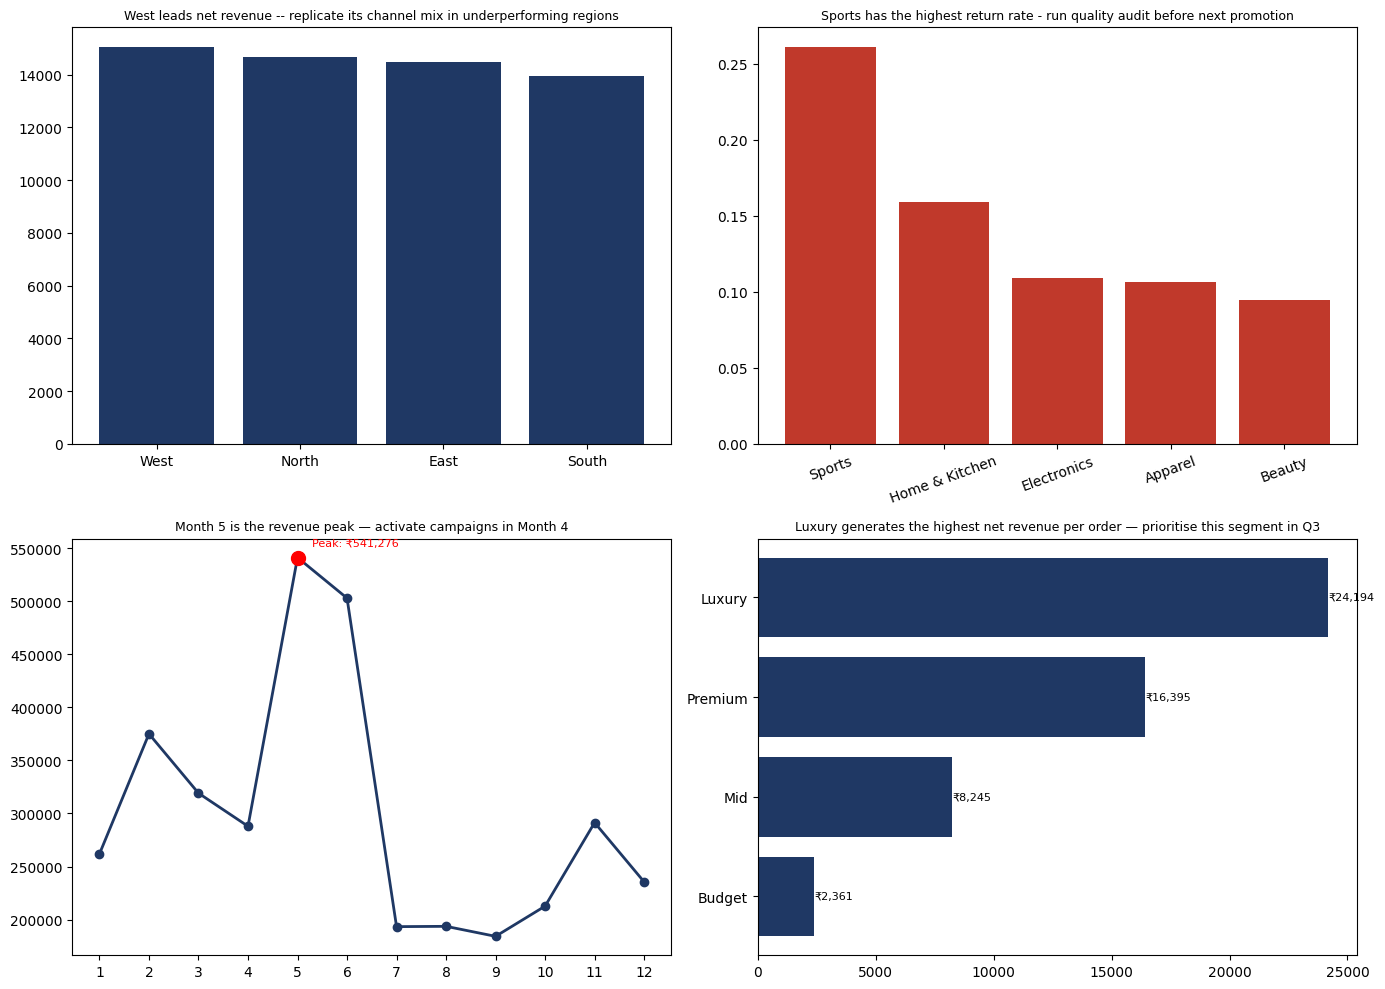

Dashboard saved as D_dashboard.png


In [10]:
# D — 2×2 Dashboard
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Build all 4 panels, insight titles, tight_layout, savefig, show
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: mean net revenue per region
reg_net = df.groupby('region')['net_revenue'].mean().sort_values(ascending = False)
axes[0,0].bar(reg_net.index, reg_net.values, color = '#1F3864')
top_r = reg_net.index[0]
axes[0,0].set_title(f'{top_r} leads net revenue -- replicate its channel mix in underperforming regions', fontsize = 9)

# Top right: return rate per category
cat_ret = df.groupby('category')['is_return'].mean().sort_values(ascending = False)
axes[0,1].bar(cat_ret.index, cat_ret.values, color='#C0392B')
axes[0,1].tick_params(axis='x', rotation=20)
top_c = cat_ret.index[0]
axes[0,1].set_title(f'{top_c} has the highest return rate - run quality audit before next promotion', fontsize=9)

# Bottom left: monthly revenue trend
monthly = df.groupby('order_month')['revenue'].sum()
peak_m  = monthly.idxmax(); peak_v = monthly.max()
axes[1,0].plot(monthly.index, monthly.values, marker='o', color='#1F3864', linewidth=2)
axes[1,0].scatter(peak_m, peak_v, color='red', s=100, zorder=5)
axes[1,0].annotate(f'Peak: ₹{peak_v:,.0f}', xy=(peak_m, peak_v),
                   xytext=(peak_m+0.3, peak_v*1.02), fontsize=8, color='red')
axes[1,0].set_xticks(monthly.index)
axes[1,0].set_title(f'Month {peak_m} is the revenue peak — activate campaigns in Month {peak_m-1}', fontsize=9)

# Bottom-right: mean net_revenue per price_tier (horizontal)
tier_net = df.groupby('price_tier', observed=True)['net_revenue'].mean().sort_values()
axes[1,1].barh(tier_net.index.astype(str), tier_net.values, color='#1F3864')
for bar, val in zip(axes[1,1].patches, tier_net.values):
    axes[1,1].text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
                   f'₹{val:,.0f}', va='center', fontsize=8)
top_t = tier_net.index[-1]
axes[1,1].set_title(f'{top_t} generates the highest net revenue per order — prioritise this segment in Q3', fontsize=9)

plt.tight_layout()
plt.savefig('D_dashboard.png', dpi=150)
plt.show()
print("Dashboard saved as D_dashboard.png")


### 🔴 Section E — Executive Summary (5 pts)

**E1 — Three Actionable Findings**

Write a `print()` block with exactly **3 findings** in NRA format.

Each finding must:
- Reference a **specific number** from your analysis (no vague claims)
- State the **reason** (why this number matters)
- Give one **concrete action** (what the business should do)

Label them: `FINDING 1:`, `FINDING 2:`, `FINDING 3:`

These must come from your actual outputs — not invented numbers.


In [11]:
# E1 — Executive Summary
# Three NRA findings from your actual analysis
reg_net  = df.groupby('region')['net_revenue'].mean().sort_values(ascending=False)
cat_ret  = df.groupby('category')['is_return'].mean().sort_values(ascending=False)
tier_shr = df.groupby('price_tier', observed=True)['shipping_ratio'].mean().sort_values(ascending=False)

print(f"""
FINDING 1: {reg_net.index[0]} leads all regions with ₹{reg_net.iloc[0]:,.0f} mean net revenue —
{(reg_net.iloc[0]/reg_net.iloc[-1]-1)*100:.0f}% higher than the weakest region ({reg_net.index[-1]}) —
conduct a channel-mix audit in {reg_net.index[-1]} and replicate {reg_net.index[0]}'s top-performing channel.

FINDING 2: {cat_ret.index[0]} has a {cat_ret.iloc[0]:.1%} return rate — the highest across all categories —
this is {(cat_ret.iloc[0]/cat_ret.mean()-1)*100:.0f}% above the average return rate of {cat_ret.mean():.1%} —
pause paid acquisition for {cat_ret.index[0]} until a product quality review is completed.

FINDING 3: {tier_shr.index[0]} tier orders carry a {tier_shr.iloc[0]:.1%} shipping-to-revenue ratio — the worst margin leak —
small-basket orders are disproportionately expensive to ship —
introduce a ₹500 minimum order value for free shipping eligibility to protect net margins.
""")



FINDING 1: West leads all regions with ₹15,036 mean net revenue —
8% higher than the weakest region (South) —
conduct a channel-mix audit in South and replicate West's top-performing channel.

FINDING 2: Sports has a 26.1% return rate — the highest across all categories —
this is 79% above the average return rate of 14.6% —
pause paid acquisition for Sports until a product quality review is completed.

FINDING 3: Budget tier orders carry a 15.5% shipping-to-revenue ratio — the worst margin leak —
small-basket orders are disproportionately expensive to ship —
introduce a ₹500 minimum order value for free shipping eligibility to protect net margins.



## 🏆 Section 4 — Scoring Rubric

| Task | Pts | Full marks require |
|------|-----|--------------------|
| A1 — Audit report | 8 | All 5 audit points printed, one per line |
| A2 — Cleaning pipeline | 12 | All 4 fixes applied, 3 assertions pass, shape printed |
| B1 — Four features | 12 | All 4 features created correctly, head(5) printed |
| B2 — Segment insight | 8 | Both tables printed, NRA insight names the tier + action |
| C1 — Revenue distribution | 5 | describe() printed, two observations using actual numbers |
| C2 — Category return rate | 8 | Grouped + sorted, NRA insight cites exact % and gap |
| C3 — Correlation check | 7 | Both r values printed, NRA identifies stronger factor |
| D — 2×2 Dashboard | 15 | All 4 panels in one figure, insight titles, saved before show |
| E1 — Executive summary | 5 | 3 NRA findings with real numbers from analysis |
| ⭐ Bonus | +10 | Dashboard saved ✓, all insights use real numbers ✓, 0 broken cells ✓, all assertions pass ✓ |

---

### ⚡ Key Takeaway — Day 46

> The full EDA loop takes 20 minutes or 20 hours depending on one habit:
> **writing the plain-English comment before the code.**
>
> Every task here has a business question. Before typing a single function name, write:
> `# I need to find X because the client wants to know Y`
> That comment forces you to understand what you're computing — which means
> you'll catch the wrong answer before you submit it, not after.

---

### Interview Frame
> *"Walk me through how you approach a messy dataset you've never seen before."*

**Answer:** "I follow a five-phase process. First, orient — shape, dtypes, sample rows, understand what each column means. Second, diagnose — null counts, duplicates, value ranges, type mismatches. Third, clean — fix nulls (median or mode fill, or flag), remove invalid rows, convert types. Fourth, engineer and explore — create ratio features, bins, date parts, then run distributions and correlations to find signal. Fifth, narrate — every finding gets a Number, a Reason, and an Action. The client doesn't want to see a DataFrame. They want three things they can act on by Monday."

---
